# House Price Prediction: From Linear Models to Gradient Boosting

## 1. Project Overview

This project develops an end-to-end machine learning pipeline for predicting residential house prices using the Kaggle House Prices dataset.

The analysis focuses not only on predictive performance, but also on understanding the statistical structure of the data, handling missing values appropriately, comparing linear and nonlinear modelling approaches, and evaluating model generalisation through cross-validation.

### Objectives

- Explore the relationships between housing characteristics and sale prices.
- Investigate missing-data patterns and distinguish structural absence from potentially genuine missingness.
- Build a simple linear-regression baseline.
- Evaluate the effect of using the full feature set.
- Apply Ridge regression to address regularisation and correlated predictors.
- Compare linear models with Random Forest and Gradient Boosting.
- Use cross-validation for hyperparameter selection.
- Analyse model errors and limitations.
- Generate predictions for the Kaggle test set.

### Evaluation Metric

Model performance is evaluated using Root Mean Squared Error (RMSE) on the logarithm of `SalePrice`. Because house prices are strongly right-skewed, the target variable is transformed using:

`log1p(SalePrice)`

Predictions are transformed back to the original price scale using `expm1()` when generating the final Kaggle submission.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


## 2. Data Understanding

In [2]:

train = pd.read_csv(
    "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
)

print("Dataset shape:", train.shape)
train.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Dataset shape:", train.shape)
print("\nTarget column:", "SalePrice")
print("\nFirst 5 rows:")
display(train.head())

Dataset shape: (1460, 81)

Target column: SalePrice

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Dataset structure

The training dataset contains 1,460 observations and 81 columns, including the target variable `SalePrice`.

The predictors include numerical, nominal categorical, ordinal, and identifier-type variables. Because storage data type does not always correspond to statistical variable type, several variables require semantic reclassification before modelling.

In [4]:
train.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

## 3. Exploratory Data Analysis

SalePrice skewness: 1.8828757597682129


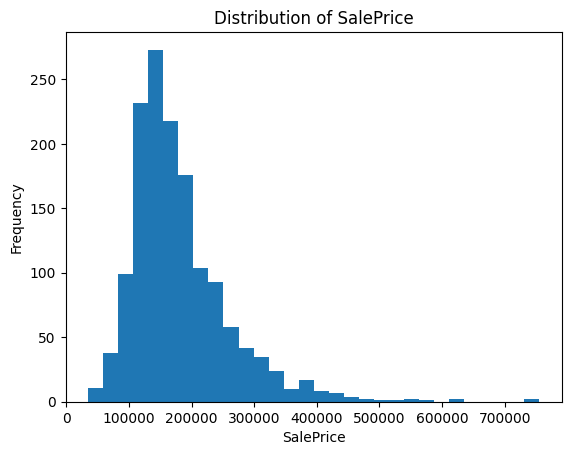

In [5]:
print("SalePrice skewness:", train['SalePrice'].skew())

plt.hist(train['SalePrice'], bins=30)
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.show()

### Target distribution

`SalePrice` is strongly right-skewed, with a skewness of approximately 1.88. This indicates that a relatively small number of high-value houses create a long upper tail.

Because RMSE is sensitive to large errors and the competition evaluates prediction error on a logarithmic scale, the target variable is transformed using `log1p()`.

Log-transformed skewness: 0.12134661989685333


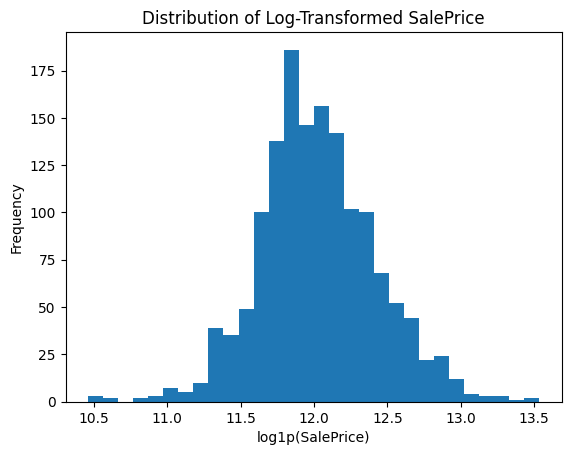

In [6]:
log_saleprice = np.log1p(train['SalePrice'])

print("Log-transformed skewness:", log_saleprice.skew())

plt.hist(log_saleprice, bins=30)
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Frequency')
plt.title('Distribution of Log-Transformed SalePrice')
plt.show()

After the transformation, skewness decreases substantially to approximately 0.12, producing a much more symmetric target distribution.

In [7]:
numeric_corr = train.corr(numeric_only=True)

top_corr = (
    numeric_corr['SalePrice']
    .sort_values(ascending=False)
    .head(11)
)

top_corr

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

### Correlation with SalePrice

Among numerical variables, `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, and `1stFlrSF` show relatively strong positive linear associations with `SalePrice`.

These correlations are descriptive rather than causal. In addition, several predictors are themselves highly correlated, which suggests potential multicollinearity in linear models.

In [8]:
train[['GarageCars', 'GarageArea']].corr()

,GarageCars,GarageArea
GarageCars,1.000000,0.882475
GarageArea,0.882475,1.000000


For example, `GarageCars` and `GarageArea` are strongly correlated. This motivates the later use of regularisation, particularly Ridge regression, to stabilise coefficient estimates in the presence of correlated predictors.

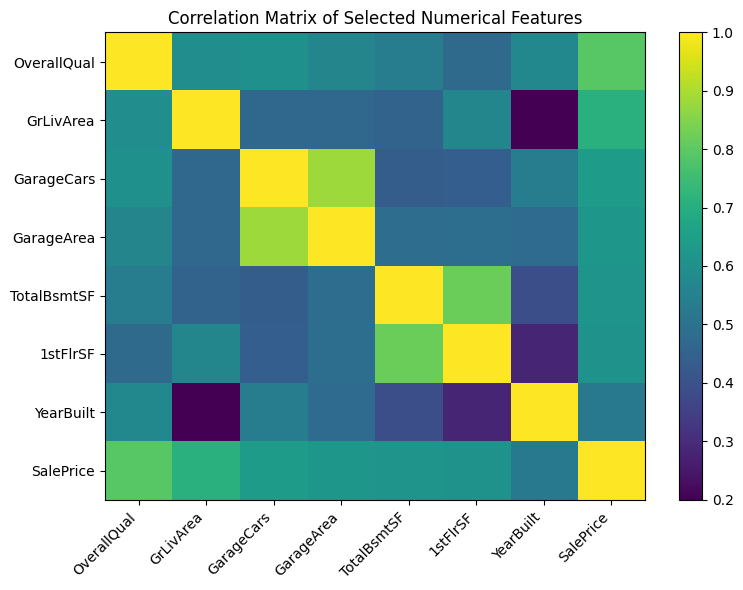

In [9]:
important_features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'YearBuilt',
    'SalePrice'
]

corr_matrix = train[important_features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect='auto')
plt.xticks(range(len(important_features)), important_features, rotation=45, ha='right')
plt.yticks(range(len(important_features)), important_features)
plt.colorbar()
plt.title('Correlation Matrix of Selected Numerical Features')
plt.tight_layout()
plt.show()

The correlation matrix highlights both target-related associations and redundancy among predictors, reinforcing the need to compare ordinary linear regression with regularised alternatives.

## 4. Missing Values and Variable Types

Missing values in this dataset do not all represent the same phenomenon. Some indicate genuine missing information, while others describe the structural absence of a house feature, such as no garage, no basement, or no pool.

Before modelling, missingness patterns are therefore examined together with the dataset documentation and related variables.

### 4.1 Missing-Value Overview

In [10]:
missing = train.isnull().sum()

missing_values = (
    missing[missing > 0]
    .sort_values(ascending=False)
)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Several variables contain large numbers of missing values. However, a high missing count does not necessarily imply poor data quality.

For example, according to the dataset definitions, missing values in variables such as `PoolQC`, `GarageType`, and several basement-related variables can represent the absence of the corresponding property feature.

### 4.2 Structural Missingness: Garage Variables

In [11]:
garage_cols = [
    'GarageType',
    'GarageYrBlt',
    'GarageFinish',
    'GarageQual',
    'GarageCond'
]

garage_missing_together = (
    train[garage_cols]
    .isnull()
    .all(axis=1)
    .sum()
)

print("Rows with all garage-related variables missing:",
      garage_missing_together)

train[garage_cols].isnull().sum()

Rows with all garage-related variables missing: 81


GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

All five garage-related variables are simultaneously missing for 81 houses. This pattern is consistent with structural absence of a garage rather than random data loss.

This distinction is important because treating all missing values as generic numerical or categorical missingness may discard meaningful information about the property.

### 4.3 Structural vs Partial Missingness: Basement Variables

Basement-related variables provide another example where missing values require contextual interpretation.

If all basement-related categorical variables are missing simultaneously, the pattern may indicate the structural absence of a basement. In contrast, partial missingness requires further investigation because other variables may indicate that a basement actually exists.

In [12]:
basement_cols = [
    'BsmtExposure',
    'BsmtFinType2',
    'BsmtQual',
    'BsmtCond',
    'BsmtFinType1'
]

all_basement_missing = (
    train[basement_cols]
    .isnull()
    .all(axis=1)
    .sum()
)

print(
    "Rows with all selected basement variables missing:",
    all_basement_missing
)

train[basement_cols].isnull().sum()

Rows with all selected basement variables missing: 37


BsmtExposure    38
BsmtFinType2    38
BsmtQual        37
BsmtCond        37
BsmtFinType1    37
dtype: int64

The missing-value counts reveal a small inconsistency. While 37 observations have all five selected basement variables missing, `BsmtExposure` and `BsmtFinType2` each contain 38 missing values.

This suggests that, in addition to the 37 observations with complete basement-related missingness, there are observations with only partial missingness. These cases require further investigation before being interpreted as structural absence.

In [13]:
partial_bsmt_missing = train[
    train[basement_cols].isnull().any(axis=1)
    & ~train[basement_cols].isnull().all(axis=1)
]

partial_bsmt_missing[
    ['Id'] + basement_cols + ['TotalBsmtSF']
]

,Id,BsmtExposure,BsmtFinType2,BsmtQual,BsmtCond,BsmtFinType1,TotalBsmtSF
332,333,No,NaN,Gd,TA,GLQ,3206
948,949,NaN,Unf,Gd,TA,Unf,936


Among the basement-related variables, 37 observations have all selected categorical fields missing simultaneously, which is consistent with structural absence of a basement.

However, two observations show partial missingness while `TotalBsmtSF` and other basement variables indicate that basement information exists. These cases should therefore not automatically be interpreted in the same way as houses with no basement.

This demonstrates the importance of examining missingness through cross-feature consistency rather than relying only on missing-value counts.

### 4.4 Statistical Variable Types

A variable's storage type does not necessarily reflect its statistical meaning.

For example, `MSSubClass` is stored numerically, but its values represent categories of dwelling type rather than continuous quantities. It is therefore treated as a categorical variable.

Similarly, `Id` is stored as an integer but serves only as an identifier and is excluded from the predictor set.

In [14]:
print(train['MSSubClass'].value_counts().sort_index())

MSSubClass
20     536
30      69
40       4
45      12
50     144
60     299
70      60
75      16
80      58
85      20
90      52
120     87
160     63
180     10
190     30
Name: count, dtype: int64


In [15]:
train['MSSubClass'] = train['MSSubClass'].astype('object')

numeric_cols = train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = train.select_dtypes(
    include=['object']
).columns

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 37
Categorical columns: 44


After reclassifying `MSSubClass`, the dataset contains both numerical and categorical predictors that require different preprocessing strategies.

This distinction is used in the modelling pipeline: numerical variables are imputed numerically, while categorical variables are imputed and one-hot encoded.

## 5. Data Preprocessing

Before model development, the dataset is prepared by separating predictors from the target, creating training and validation subsets, transforming the target variable, and constructing a preprocessing pipeline for numerical and categorical features.

All preprocessing operations are fitted using the training data rather than the validation data to reduce data leakage.

### 5.1 Feature-Target Separation

`SalePrice` is the prediction target and is therefore separated from the predictor matrix.

The `Id` variable is also removed from the predictors because it functions as a record identifier rather than a meaningful housing characteristic.

The remaining variables form the feature matrix `X`, while `SalePrice` forms the target vector `y`.

In [16]:
X = train.drop(columns=['SalePrice', 'Id'])
y = train['SalePrice']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (1460, 79)
Target vector shape: (1460,)


After removing the target and identifier columns, the modelling dataset contains 79 predictor variables for 1,460 observations.

### 5.2 Train-Validation Split

The dataset is divided into training and validation subsets using an 80/20 split.

The training subset is used to fit the models, while the validation subset provides a consistent hold-out sample for comparing model behaviour during development.

A fixed `random_state` is used to make the split reproducible.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1168, 79)
X_valid shape: (292, 79)
y_train shape: (1168,)
y_valid shape: (292,)


The split produces 1,168 training observations and 292 validation observations.

The validation set is used as a development benchmark rather than as a completely untouched final test set, since model performance on this split is inspected during model development.

### 5.3 Target Transformation

Exploratory analysis showed that `SalePrice` is strongly right-skewed. A small number of very expensive houses create a long upper tail.

To obtain a more symmetric target distribution and align the modelling process with the competition's logarithmic evaluation metric, the target is transformed using:

`log1p(SalePrice)`

where `log1p(x)` computes `log(1 + x)`.

In [18]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

print("Original training target skewness:",
      y_train.skew())

print("Log-transformed training target skewness:",
      y_train_log.skew())

Original training target skewness: 1.743128561420854
Log-transformed training target skewness: 0.12489024367919238


In [19]:
print("MSSubClass dtype:", train['MSSubClass'].dtype)
print("X MSSubClass dtype:", X['MSSubClass'].dtype)
print("X_train MSSubClass dtype:", X_train['MSSubClass'].dtype)

MSSubClass dtype: object
X MSSubClass dtype: object
X_train MSSubClass dtype: object


The logarithmic transformation substantially reduces the right-skewness of the target distribution.

Models are therefore trained to predict log-transformed house prices. Predictions can later be converted back to the original price scale using `expm1()`.

### 5.4 Preprocessing Pipeline

The predictors contain both numerical and categorical variables, so different preprocessing strategies are required.

Numerical missing values are imputed using the median. Categorical missing values are represented using a constant placeholder and categorical variables are subsequently transformed through one-hot encoding.

`OneHotEncoder(handle_unknown='ignore')` is used so that previously unseen categories in validation or test data do not cause prediction errors.

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Number of numerical features:",
      len(numeric_features))

print("Number of categorical features:",
      len(categorical_features))

Number of numerical features: 35
Number of categorical features: 44


In [21]:
numeric_transformer = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(strategy='median')
    )
])

categorical_transformer = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='Missing'
        )
    ),
    (
        'onehot',
        OneHotEncoder(handle_unknown='ignore')
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

### 5.5 Inspecting the Processed Feature Space

The preprocessing pipeline is fitted on the training data and then applied to both the training and validation sets.

Fitting preprocessing operations only on the training data reduces the risk of data leakage, because information from the validation set is not used to determine imputation values or encoded categories.

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Original training feature space:",
      X_train.shape)

print("Processed training feature space:",
      X_train_processed.shape)

print("Processed validation feature space:",
      X_valid_processed.shape)

Original training feature space: (1168, 79)
Processed training feature space: (1168, 315)
Processed validation feature space: (292, 315)


After preprocessing, the original 79 predictors expand to 315 model-ready features.

This increase is primarily driven by one-hot encoding, which represents categorical variables using multiple binary indicator features.

The expanded feature space may contain correlated and redundant predictors, which motivates the comparison between ordinary linear regression and regularised models such as Ridge regression.

### 5.6 Preprocessing Limitation

The current preprocessing pipeline uses a consistent baseline strategy by assigning the label `Missing` to all missing categorical values.

However, the earlier missing-value analysis showed that some missing values have specific semantic meanings, such as the absence of a garage, basement, pool, or fence. Therefore, the current preprocessing pipeline does not fully distinguish structural absence from genuinely unknown information.

A more semantically informed missing-value treatment could be explored as a future improvement.

## 6. Model Development

A sequence of regression models is developed to examine how predictive performance changes as model complexity and regularisation are introduced.

The modelling process begins with a simple and interpretable linear-regression baseline using only three predictors. It then expands to the complete feature set before introducing regularised and nonlinear models.

All models are evaluated using RMSE on the log-transformed target, where lower values indicate better predictive performance.

### 6.1 Simple Linear Regression Baseline

A simple linear regression model is first constructed using three intuitive numerical predictors:

- `OverallQual`: overall material and finish quality
- `GrLivArea`: above-ground living area
- `YearBuilt`: original construction year

These variables showed meaningful associations with `SalePrice` during exploratory analysis and provide an interpretable baseline before the full feature set is introduced.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

baseline_features = [
    'OverallQual',
    'GrLivArea',
    'YearBuilt'
]

baseline_model = LinearRegression()

baseline_model.fit(
    X_train[baseline_features],
    y_train_log
)

baseline_pred = baseline_model.predict(
    X_valid[baseline_features]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        baseline_pred
    )
)

print("3-feature Linear Regression RMSE:",
      baseline_rmse)

3-feature Linear Regression RMSE: 0.1871750285777076


The three-feature linear regression model achieves a validation RMSE of approximately **0.1872**.

This establishes a simple benchmark using only a small subset of the available information. Although the selected predictors individually show relatively strong relationships with house prices, substantial predictive information remains unused in the other features.

### 6.2 Full-Feature Linear Regression

The linear regression model is next extended to the complete predictor set.

Unlike the three-feature baseline, this model incorporates both numerical and categorical housing characteristics. The preprocessing pipeline handles missing values and converts categorical variables into model-ready one-hot encoded features.

Combining preprocessing and modelling within a single pipeline also ensures that the same transformations are consistently applied to training and validation data.

In [24]:
full_linear_model = Pipeline(steps=[
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        LinearRegression()
    )
])

full_linear_model.fit(
    X_train,
    y_train_log
)

full_linear_pred = full_linear_model.predict(
    X_valid
)

full_linear_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        full_linear_pred
    )
)

print("Full-feature Linear Regression RMSE:",
      full_linear_rmse)

Full-feature Linear Regression RMSE: 0.14247070789577196


Using the complete feature set reduces validation RMSE from approximately **0.1872** to **0.1425**.

This substantial improvement indicates that house prices depend on information distributed across many property characteristics rather than only overall quality, living area, and construction year.

However, one-hot encoding expands the predictor space to 315 features, and exploratory analysis also identified substantial correlation among some predictors. Ordinary linear regression does not explicitly control coefficient magnitude, motivating the use of Ridge regularisation in the next stage.

### Why Regularisation?

Expanding the model from 79 raw predictors to 315 processed features increases the dimensionality of the feature space. In addition, exploratory analysis identified strong correlations between some predictors; for example, `GarageCars` and `GarageArea` have a correlation of approximately 0.88.

These characteristics can make ordinary linear-regression coefficients more sensitive to correlated and redundant predictors.

Ridge regression addresses this by adding an L2 penalty to the ordinary least-squares objective:

\[
\text{Loss} = \text{RSS} + \alpha \sum_{j=1}^{p}\beta_j^2
\]

The penalty discourages excessively large coefficients while retaining all predictors. The next experiment therefore evaluates whether Ridge regularisation improves generalisation over ordinary linear regression.

### 6.3 Ridge Regression

Ridge regression extends ordinary linear regression by adding L2 regularisation, which shrinks coefficient magnitudes and can improve model stability when predictors are numerous or correlated.

Because Ridge is sensitive to feature scale, numerical predictors are standardised before model fitting. Categorical predictors continue to be imputed and one-hot encoded.

The regularisation strength `alpha` is selected using 5-fold cross-validation rather than the hold-out validation set.

In [25]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

ridge_numeric_transformer = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

ridge_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            ridge_numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### Cross-Validation for Alpha Selection

The hyperparameter `alpha` controls the strength of Ridge regularisation. A larger value imposes stronger coefficient shrinkage, while a value closer to zero approaches ordinary linear regression.

Five candidate values are evaluated using the same 5-fold cross-validation procedure. RMSE is calculated for each fold, and the alpha with the lowest mean cross-validation RMSE is selected.

In [26]:
ridge_alphas = [0.01, 0.1, 1, 10, 100]

ridge_cv_results = []

for alpha in ridge_alphas:
    ridge_model_cv = Pipeline(steps=[
        (
            'preprocessor',
            ridge_preprocessor
        ),
        (
            'model',
            Ridge(alpha=alpha)
        )
    ])

    scores = cross_val_score(
        ridge_model_cv,
        X_train,
        y_train_log,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    rmse_scores = -scores

    ridge_cv_results.append({
        'alpha': alpha,
        'mean_cv_rmse': rmse_scores.mean(),
        'std_cv_rmse': rmse_scores.std()
    })

ridge_cv_results = pd.DataFrame(ridge_cv_results)

ridge_cv_results

,alpha,mean_cv_rmse,std_cv_rmse
0,0.01,0.163475,0.024592
1,0.10,0.158864,0.025648
2,1.00,0.148006,0.027469
3,10.00,0.140364,0.029280
4,100.00,0.141756,0.031695


In [27]:
best_ridge_row = ridge_cv_results.loc[
    ridge_cv_results['mean_cv_rmse'].idxmin()
]

best_ridge_alpha = best_ridge_row['alpha']

print("Best alpha:", best_ridge_alpha)
print(
    "Best mean CV RMSE:",
    best_ridge_row['mean_cv_rmse']
)
print(
    "CV RMSE standard deviation:",
    best_ridge_row['std_cv_rmse']
)

Best alpha: 10.0
Best mean CV RMSE: 0.14036428616571056
CV RMSE standard deviation: 0.029279781862225726


#### Ridge Cross-Validation Results

Cross-validation performance improves as the regularisation strength increases from `alpha = 0.01` to `alpha = 10`.

The lowest mean cross-validation RMSE is obtained at:

- **alpha = 10**
- **Mean CV RMSE = 0.1404**
- **CV RMSE standard deviation = 0.0293**

Increasing the regularisation strength further to `alpha = 100` slightly worsens the mean CV RMSE to approximately 0.1418.

Therefore, `alpha = 10` is selected for the final Ridge model.

#### Final Ridge Model

Using the cross-validation result, a Ridge regression model with `alpha = 10` is fitted on the complete training subset and evaluated on the hold-out validation subset.

The validation set was not used to select `alpha` in this experiment; hyperparameter selection was based on cross-validation within the training data.

In [28]:
ridge_model = Pipeline(steps=[
    (
        'preprocessor',
        ridge_preprocessor
    ),
    (
        'model',
        Ridge(alpha=best_ridge_alpha)
    )
])

ridge_model.fit(
    X_train,
    y_train_log
)

ridge_pred = ridge_model.predict(
    X_valid
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        ridge_pred
    )
)

print("Ridge Validation RMSE:", ridge_rmse)

Ridge Validation RMSE: 0.137456375061391


In [29]:
print("3-feature Linear Regression:",
      baseline_rmse)

print("Full-feature Linear Regression:",
      full_linear_rmse)

print("Ridge Regression:",
      ridge_rmse)

3-feature Linear Regression: 0.1871750285777076
Full-feature Linear Regression: 0.14247070789577196
Ridge Regression: 0.137456375061391


#### Ridge Regression Performance

Ridge regression achieves a validation RMSE of approximately **0.1375**, improving upon the full-feature ordinary linear regression RMSE of **0.1425** and the three-feature baseline RMSE of **0.1872**.

The improvement from full-feature linear regression to Ridge suggests that regularisation is beneficial in the expanded feature space, where correlated and redundant predictors are present.

Among the linear models evaluated so far, Ridge regression provides the strongest validation performance.

### 6.4 Random Forest Regression

The previous models assume that the relationship between the predictors and log-transformed house prices can be represented through linear combinations of features.

However, housing characteristics may also exhibit nonlinear relationships and interactions. For example, the effect of living area may differ depending on overall quality, neighbourhood, or other property characteristics.

A Random Forest regressor is therefore evaluated as a nonlinear ensemble alternative. Random Forest combines predictions from many decision trees and can capture nonlinear relationships and feature interactions without explicitly specifying them.

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(
    X_train,
    y_train_log
)

rf_pred = rf_model.predict(
    X_valid
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        rf_pred
    )
)

print("Random Forest Validation RMSE:",
      rf_rmse)

Random Forest Validation RMSE: 0.14564652606286976


In [31]:
print("3-feature Linear Regression:",
      baseline_rmse)

print("Full-feature Linear Regression:",
      full_linear_rmse)

print("Ridge Regression:",
      ridge_rmse)

print("Random Forest:",
      rf_rmse)

3-feature Linear Regression: 0.1871750285777076
Full-feature Linear Regression: 0.14247070789577196
Ridge Regression: 0.137456375061391
Random Forest: 0.14564652606286976


#### Random Forest Performance

The Random Forest model achieves a validation RMSE of approximately **0.1456**. This is substantially better than the simple three-feature baseline, but worse than both the full-feature linear regression (**0.1425**) and Ridge regression (**0.1375**).

This result demonstrates that greater model complexity does not necessarily lead to better predictive performance. Although Random Forest can capture nonlinear relationships and feature interactions, its default configuration does not outperform the regularised linear model on the current validation split.

Ridge therefore remains the strongest model at this stage.

### 6.5 Gradient Boosting Regression

The weaker performance of Random Forest does not imply that nonlinear tree-based models are unsuitable for this problem. Different ensemble methods construct and combine decision trees in different ways.

Random Forest builds many trees and aggregates their predictions, whereas Gradient Boosting builds trees sequentially, with each stage attempting to improve upon the errors of the existing ensemble.

Gradient Boosting is therefore evaluated as a second nonlinear modelling approach.

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_default = Pipeline(steps=[
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gbr_default.fit(
    X_train,
    y_train_log
)

gbr_default_pred = gbr_default.predict(
    X_valid
)

gbr_default_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        gbr_default_pred
    )
)

print(
    "Default Gradient Boosting Validation RMSE:",
    gbr_default_rmse
)

Default Gradient Boosting Validation RMSE: 0.13830521147284253


In [33]:
print("Ridge Regression:",
      ridge_rmse)

print("Random Forest:",
      rf_rmse)

print("Default Gradient Boosting:",
      gbr_default_rmse)

Ridge Regression: 0.137456375061391
Random Forest: 0.14564652606286976
Default Gradient Boosting: 0.13830521147284253


#### Default Gradient Boosting Performance

The default Gradient Boosting model achieves a validation RMSE of approximately **0.1383**.

This substantially outperforms Random Forest (**0.1456**) and approaches the performance of Ridge regression (**0.1375**), although Ridge remains slightly better on the current validation split.

The strong performance of the default Gradient Boosting model suggests that boosting is promising for this dataset. The next step therefore evaluates whether its performance can be improved through cross-validated hyperparameter selection.

#### 6.5.1 Hyperparameter Selection with Cross-Validation

Gradient Boosting performance depends on several interacting hyperparameters. Three key parameters are examined:

- `n_estimators`: the number of boosting stages
- `learning_rate`: the contribution of each successive tree
- `max_depth`: the maximum depth of the individual regression trees

Six candidate configurations are compared using the same shuffled 5-fold cross-validation strategy used during Ridge model selection.

The configuration with the lowest mean cross-validation RMSE is selected.

In [34]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [35]:
gbr_params = [
    (500, 0.03, 2),
    (500, 0.03, 3),
    (300, 0.05, 2),
    (300, 0.05, 3),
    (200, 0.10, 2),
    (200, 0.10, 3)
]

gbr_cv_results = []

for n_estimators, learning_rate, max_depth in gbr_params:
    
    gbr_model_cv = Pipeline(steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            GradientBoostingRegressor(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                random_state=42
            )
        )
    ])
    
    scores = cross_val_score(
        gbr_model_cv,
        X_train,
        y_train_log,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )
    
    rmse_scores = -scores
    
    gbr_cv_results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'mean_cv_rmse': rmse_scores.mean(),
        'std_cv_rmse': rmse_scores.std()
    })

gbr_cv_results = pd.DataFrame(gbr_cv_results)

gbr_cv_results

,n_estimators,learning_rate,max_depth,mean_cv_rmse,std_cv_rmse
0,500,0.03,2,0.129568,0.017809
1,500,0.03,3,0.128264,0.016510
2,300,0.05,2,0.129215,0.016538
3,300,0.05,3,0.128840,0.016000
4,200,0.10,2,0.129561,0.017738
5,200,0.10,3,0.130664,0.014811


In [36]:
best_gbr_row = gbr_cv_results.loc[
    gbr_cv_results['mean_cv_rmse'].idxmin()
]

print("Best parameters:")
print(
    "n_estimators =",
    int(best_gbr_row['n_estimators'])
)
print(
    "learning_rate =",
    best_gbr_row['learning_rate']
)
print(
    "max_depth =",
    int(best_gbr_row['max_depth'])
)
print(
    "Best mean CV RMSE =",
    best_gbr_row['mean_cv_rmse']
)
print(
    "CV RMSE standard deviation =",
    best_gbr_row['std_cv_rmse']
)

Best parameters:
n_estimators = 500
learning_rate = 0.03
max_depth = 3
Best mean CV RMSE = 0.12826439399030334
CV RMSE standard deviation = 0.01651010110649104


#### Gradient Boosting Cross-Validation Results

Among the six candidate configurations, the best cross-validation performance is achieved with:

- `n_estimators = 500`
- `learning_rate = 0.03`
- `max_depth = 3`
- Mean CV RMSE = **0.1283**
- CV RMSE standard deviation = **0.0165**

The results also illustrate the interaction between learning rate and the number of boosting stages. The best-performing configuration combines a relatively small learning rate with a larger number of estimators, allowing the ensemble to improve predictions gradually across more boosting stages.

This configuration is selected for the tuned Gradient Boosting model.

#### 6.5.2 Tuned Gradient Boosting Model

The best-performing hyperparameter configuration identified through cross-validation is fitted on the complete training subset and evaluated on the hold-out validation subset.

This allows the tuned Gradient Boosting model to be compared directly with the previous linear and ensemble models using the same validation data.

In [37]:
tuned_gbr_model = Pipeline(steps=[
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            random_state=42
        )
    )
])

tuned_gbr_model.fit(
    X_train,
    y_train_log
)

tuned_gbr_pred = tuned_gbr_model.predict(
    X_valid
)

tuned_gbr_rmse = np.sqrt(
    mean_squared_error(
        y_valid_log,
        tuned_gbr_pred
    )
)

print(
    "Tuned Gradient Boosting Validation RMSE:",
    tuned_gbr_rmse
)

Tuned Gradient Boosting Validation RMSE: 0.13626437822818693


In [38]:
model_results = pd.DataFrame({
    'Model': [
        '3-Feature Linear Regression',
        'Full-Feature Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'Default Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Validation RMSE': [
        baseline_rmse,
        full_linear_rmse,
        ridge_rmse,
        rf_rmse,
        gbr_default_rmse,
        tuned_gbr_rmse
    ]
})

model_results = model_results.sort_values(
    'Validation RMSE'
).reset_index(drop=True)

model_results

,Model,Validation RMSE
0,Tuned Gradient Boosting,0.136264
1,Ridge Regression,0.137456
2,Default Gradient Boosting,0.138305
3,Full-Feature Linear Regression,0.142471
4,Random Forest,0.145647
5,3-Feature Linear Regression,0.187175


### 6.6 Model Comparison

The tuned Gradient Boosting model achieves the lowest validation RMSE among the models evaluated, with a score of approximately **0.1363**.

Ridge regression follows closely with an RMSE of **0.1375**, while the default Gradient Boosting model achieves **0.1383**. The relatively small difference between these models suggests that the tuned Gradient Boosting model provides a modest improvement rather than a dramatic performance gain.

Several broader patterns emerge from the modelling experiments:

- Expanding from three predictors to the full feature set substantially improves predictive performance.
- Ridge regularisation improves upon ordinary full-feature linear regression.
- Random Forest does not outperform the regularised linear model, demonstrating that greater model complexity does not automatically improve generalisation.
- Gradient Boosting performs strongly even with default parameters and achieves the best validation result after cross-validated hyperparameter selection.

Based on the current experiments, the tuned Gradient Boosting model is selected as the final predictive model.

## 7. Error Analysis

Model evaluation should consider not only aggregate performance metrics but also the observations on which the model makes large prediction errors.

The tuned Gradient Boosting model is therefore examined by comparing predicted and observed log house prices on the validation set. Residuals are defined as:

\[
\text{Residual} =
\text{Actual Log Price} -
\text{Predicted Log Price}
\]

A negative residual indicates that the model overpredicts the house price, while a positive residual indicates underprediction.

In [39]:
error_analysis = X_valid.copy()

error_analysis['ActualLogPrice'] = y_valid_log
error_analysis['PredictedLogPrice'] = tuned_gbr_pred

error_analysis['Residual'] = (
    error_analysis['ActualLogPrice']
    - error_analysis['PredictedLogPrice']
)

error_analysis['AbsoluteResidual'] = (
    error_analysis['Residual'].abs()
)

largest_errors = error_analysis.sort_values(
    'AbsoluteResidual',
    ascending=False
).head(10)

largest_errors[
    [
        'OverallQual',
        'GrLivArea',
        'YearBuilt',
        'Neighborhood',
        'OverallCond',
        'ActualLogPrice',
        'PredictedLogPrice',
        'Residual'
    ]
]

,OverallQual,GrLivArea,YearBuilt,Neighborhood,OverallCond,ActualLogPrice,PredictedLogPrice,Residual
30,4,1317,1920,IDOTRR,4,10.596660,11.469210,-0.872550
916,2,480,1949,IDOTRR,3,10.471978,11.065680,-0.593701
812,5,1044,1952,IDOTRR,5,10.933000,11.458661,-0.525661
1432,4,968,1927,OldTown,6,11.074436,11.570609,-0.496173
774,8,1973,2006,NridgHt,5,12.886644,12.435769,0.450875
898,9,2364,2009,NridgHt,5,13.323929,12.892242,0.431687
588,5,1473,1968,ClearCr,8,11.870607,12.287025,-0.416418
691,10,4316,1994,NoRidge,6,13.534474,13.152944,0.381530
581,8,2042,2008,NridgHt,5,12.442306,12.790618,-0.348312
607,5,2008,1948,Edwards,8,12.323860,11.999306,0.324554


### 7.1 Errors on the Original Price Scale

Log-scale residuals are useful for model evaluation but are less intuitive in monetary terms. To make the prediction errors easier to interpret, actual and predicted log prices are transformed back to the original price scale using `expm1()`.

The ten largest errors are still identified using absolute residuals on the **log-price scale**, rather than absolute monetary errors. This keeps the error analysis consistent with the model evaluation metric.

Ranking observations by absolute dollar error would disproportionately emphasise expensive houses, since the same relative prediction error naturally corresponds to a larger monetary difference for a higher-priced property.

Dollar-scale errors are therefore reported for interpretability, while log-scale residuals are used to identify the largest model errors.

In [40]:
error_analysis['ActualPrice'] = np.expm1(
    error_analysis['ActualLogPrice']
)

error_analysis['PredictedPrice'] = np.expm1(
    error_analysis['PredictedLogPrice']
)

error_analysis['PriceError'] = (
    error_analysis['ActualPrice']
    - error_analysis['PredictedPrice']
)

error_analysis['AbsolutePriceError'] = (
    error_analysis['PriceError'].abs()
)

largest_errors = error_analysis.sort_values(
    'AbsoluteResidual',
    ascending=False
).head(10)

largest_errors[
    [
        'OverallQual',
        'GrLivArea',
        'YearBuilt',
        'Neighborhood',
        'OverallCond',
        'ActualPrice',
        'PredictedPrice',
        'PriceError',
        'Residual'
    ]
].round(2)

,OverallQual,GrLivArea,YearBuilt,Neighborhood,OverallCond,ActualPrice,PredictedPrice,PriceError,Residual
30,4,1317,1920,IDOTRR,4,40000.0,95721.61,-55721.61,-0.87
916,2,480,1949,IDOTRR,3,35311.0,63937.67,-28626.67,-0.59
812,5,1044,1952,IDOTRR,5,55993.0,94717.17,-38724.17,-0.53
1432,4,968,1927,OldTown,6,64500.0,105936.92,-41436.92,-0.50
774,8,1973,2006,NridgHt,5,395000.0,251642.51,143357.49,0.45
898,9,2364,2009,NridgHt,5,611657.0,397217.51,214439.49,0.43
588,5,1473,1968,ClearCr,8,143000.0,216862.92,-73862.92,-0.42
691,10,4316,1994,NoRidge,6,755000.0,515525.56,239474.44,0.38
581,8,2042,2008,NridgHt,5,253293.0,358834.18,-105541.18,-0.35
607,5,2008,1948,Edwards,8,225000.0,162640.94,62359.06,0.32


#### Initial Error Patterns

The largest prediction errors reveal several notable cases at both ends of the price distribution.

Several unusually low-priced properties are substantially overpredicted. For example, a house sold for \$40,000 is predicted at approximately \$95,722. Conversely, some high-priced properties are substantially underpredicted, including a \$755,000 property predicted at approximately \$515,526 and a \$611,657 property predicted at approximately \$397,218.

These extreme cases suggest a possible tendency for predictions to move toward the middle of the price distribution. However, the pattern is not universal, and the ten largest errors alone are insufficient to establish a systematic relationship.

The residual pattern is therefore examined across the complete validation set.

### 7.2 Residual Pattern Across House Prices

The largest individual errors suggest a possible tendency to overpredict some low-priced properties and underpredict some high-priced properties.

However, conclusions should not be based only on the ten largest errors. To investigate whether this pattern is more systematic, residuals are examined across the full validation set.

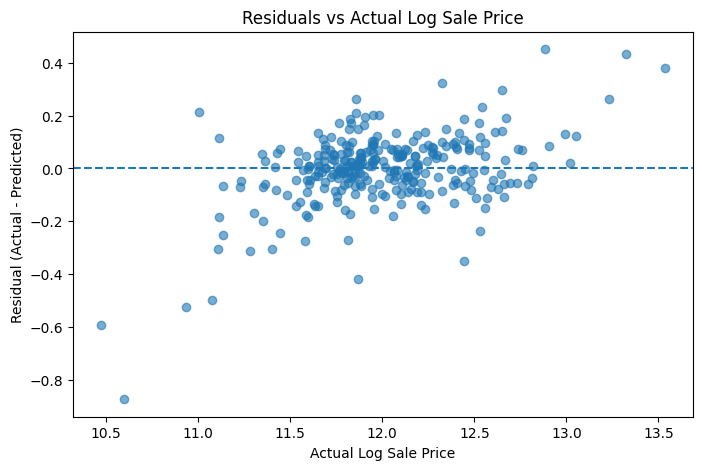

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis['ActualLogPrice'],
    error_analysis['Residual'],
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Actual Log Sale Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Actual Log Sale Price')

plt.show()

In [42]:
residual_price_corr = (
    error_analysis[
        ['ActualLogPrice', 'Residual']
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between actual log price and residual:",
    residual_price_corr
)

Correlation between actual log price and residual: 0.4437946224320995


#### Residual Pattern Interpretation

Across the full validation set, the correlation between actual log sale price and the model residual is approximately **0.44**, indicating a moderate positive relationship.

Because residuals are defined as actual minus predicted log price, this pattern suggests that the model tends to overpredict some lower-priced properties and underpredict some higher-priced properties.

The residual plot supports this interpretation: several of the largest negative residuals occur among lower-priced houses, while several large positive residuals occur toward the upper end of the price distribution.

However, the relationship is not deterministic. Most observations remain relatively close to zero, and both positive and negative residuals occur across much of the price range. The result is therefore interpreted as a tendency toward the middle of the price distribution rather than a universal prediction pattern.

### 7.3 Neighborhood-Level Error Analysis

Several neighbourhoods appear repeatedly among the observations with the largest prediction errors. For example, `IDOTRR` and `NridgHt` each occur multiple times among the ten largest log-scale residuals.

However, individual extreme cases are insufficient to conclude that the model systematically performs poorly within a particular neighbourhood.

To investigate this pattern more systematically, prediction errors are aggregated by neighbourhood across the complete validation set. Both the number of observations and the mean absolute log residual are examined, since error estimates based on very small groups may be unstable.

In [43]:
neighborhood_errors = (
    error_analysis
    .groupby('Neighborhood')
    .agg(
        SampleSize=('AbsoluteResidual', 'size'),
        MeanAbsoluteResidual=('AbsoluteResidual', 'mean'),
        MedianAbsoluteResidual=('AbsoluteResidual', 'median')
    )
    .sort_values(
        'MeanAbsoluteResidual',
        ascending=False
    )
)

neighborhood_errors.round(4)

,SampleSize,MeanAbsoluteResidual,MedianAbsoluteResidual
Neighborhood,,,
IDOTRR,11,0.2592,0.1696
NridgHt,16,0.1471,0.0875
Crawfor,7,0.1441,0.1730
StoneBr,5,0.1349,0.1302
ClearCr,9,0.1230,0.0765
SWISU,4,0.1195,0.1191
Edwards,13,0.1179,0.0909
NoRidge,8,0.1178,0.0793
BrkSide,13,0.0955,0.0668


Because neighbourhood-level error estimates may be unreliable when only a few validation observations are available, a second comparison focuses on neighbourhoods represented by at least ten validation properties.

In [44]:
neighborhood_errors_10 = (
    neighborhood_errors[
        neighborhood_errors['SampleSize'] >= 10
    ]
    .sort_values(
        'MeanAbsoluteResidual',
        ascending=False
    )
)

neighborhood_errors_10.round(4)

,SampleSize,MeanAbsoluteResidual,MedianAbsoluteResidual
Neighborhood,,,
IDOTRR,11,0.2592,0.1696
NridgHt,16,0.1471,0.0875
Edwards,13,0.1179,0.0909
BrkSide,13,0.0955,0.0668
OldTown,22,0.0954,0.0572
SawyerW,15,0.0830,0.0774
Somerst,17,0.0755,0.0751
Sawyer,16,0.0685,0.0403
Gilbert,14,0.0677,0.0529


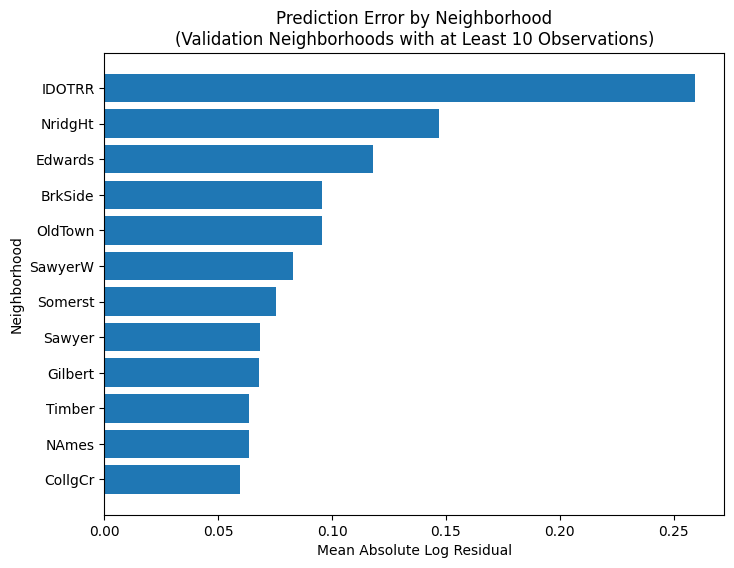

In [45]:
plot_data = (
    neighborhood_errors_10
    .sort_values(
        'MeanAbsoluteResidual',
        ascending=True
    )
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_data.index,
    plot_data['MeanAbsoluteResidual']
)

plt.xlabel('Mean Absolute Log Residual')
plt.ylabel('Neighborhood')
plt.title(
    'Prediction Error by Neighborhood\n'
    '(Validation Neighborhoods with at Least 10 Observations)'
)

plt.show()

#### Neighborhood-Level Error Interpretation

Prediction errors vary substantially across neighbourhoods in the validation set.

Among neighbourhoods represented by at least ten validation observations, `IDOTRR` has the highest mean absolute log residual (**0.2592**) and also the highest median absolute log residual (**0.1696**). Because both the mean and median errors are relatively high across 11 observations, its poor performance cannot be attributed solely to a single extreme prediction.

`NridgHt` also exhibits a relatively high mean absolute residual (**0.1471**) across 16 observations. However, its lower median residual (**0.0875**) suggests that some particularly large errors may contribute disproportionately to its mean error. This is consistent with the earlier observation that several high-priced `NridgHt` properties appear among the largest individual prediction errors.

In contrast, larger validation groups such as `NAmes` and `CollgCr` show substantially lower mean absolute residuals of approximately **0.0634** and **0.0598**, respectively.

These results suggest that model performance is not uniform across neighbourhoods. However, the analysis does not establish that neighbourhood itself causes prediction error. Differences may reflect variation in property characteristics, price distributions, sample sizes, or interactions between neighbourhood and other housing features.

## 8. Final Model and Kaggle Submission

The modelling experiments identified the tuned Gradient Boosting model as the strongest-performing model on the development validation split.

Its hyperparameters were selected using 5-fold cross-validation:

- `n_estimators = 500`
- `learning_rate = 0.03`
- `max_depth = 3`

The selected model achieved a validation RMSE of approximately **0.1363**.

After model selection and error analysis, the final model is retrained using the complete training dataset so that all available labelled observations can contribute to the final Kaggle predictions.

### 8.1 Retraining on the Full Training Dataset

During model development, 20% of the labelled observations were reserved as a validation subset for model comparison and error analysis.

Once the final model configuration has been selected, this split is no longer required for the Kaggle submission. The tuned Gradient Boosting model is therefore retrained using all 1,460 labelled training observations.

The target remains log-transformed using `log1p(SalePrice)`, consistent with the modelling and evaluation procedure used during model development.

In [46]:
X_all = train.drop(
    columns=['SalePrice', 'Id']
)

y_all_log = np.log1p(
    train['SalePrice']
)

print(
    "Full training feature shape:",
    X_all.shape
)

print(
    "Full training target shape:",
    y_all_log.shape
)

Full training feature shape: (1460, 79)
Full training target shape: (1460,)


In [47]:
print(
    "MSSubClass dtype:",
    X_all['MSSubClass'].dtype
)

MSSubClass dtype: object


In [48]:
final_numeric_features = (
    X_all
    .select_dtypes(
        include=['int64', 'float64']
    )
    .columns
    .tolist()
)

final_categorical_features = (
    X_all
    .select_dtypes(
        include=['object']
    )
    .columns
    .tolist()
)

print(
    "Numerical features:",
    len(final_numeric_features)
)

print(
    "Categorical features:",
    len(final_categorical_features)
)

Numerical features: 35
Categorical features: 44


The final preprocessing pipeline follows the same strategy used during model development. Numerical predictors are imputed using their median values, while categorical predictors are assigned a `Missing` category and one-hot encoded.

The preprocessing pipeline is fitted using the complete labelled training dataset only. The Kaggle test data are transformed using the preprocessing parameters learned from the training data.

In [49]:
final_numeric_transformer = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(strategy='median')
    )
])

final_categorical_transformer = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='Missing'
        )
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            final_numeric_transformer,
            final_numeric_features
        ),
        (
            'cat',
            final_categorical_transformer,
            final_categorical_features
        )
    ]
)

In [50]:
final_model = Pipeline(steps=[
    (
        'preprocessor',
        final_preprocessor
    ),
    (
        'model',
        GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            random_state=42
        )
    )
])

In [51]:
final_model.fit(
    X_all,
    y_all_log
)

print(
    "Final Gradient Boosting model trained successfully."
)

Final Gradient Boosting model trained successfully.


The final Gradient Boosting pipeline is fitted using all **1,460 labelled observations**.

At this stage, the validation subset used during model development is returned to the training data because model selection has already been completed. This allows the final model to use all available labelled information before generating predictions for the unseen Kaggle test set.

The Kaggle test set is not used during model fitting.

### 8.2 Preparing the Kaggle Test Set

The Kaggle test dataset contains the same predictor variables as the training dataset but does not include `SalePrice`, since these are the values to be predicted.

Before generating predictions, the test data are checked for consistency with the training feature space. In particular, `MSSubClass` is treated as a categorical variable in both datasets, and the identifier column `Id` is excluded from the model predictors while being retained for the final submission file.

In [52]:
test = pd.read_csv(
    "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"
)

print(
    "Test dataset shape:",
    test.shape
)

display(
    test.head()
)

Test dataset shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [53]:
test['MSSubClass'] = (
    test['MSSubClass']
    .astype('object')
)

print(
    "Train MSSubClass dtype:",
    X_all['MSSubClass'].dtype
)

print(
    "Test MSSubClass dtype:",
    test['MSSubClass'].dtype
)

Train MSSubClass dtype: object
Test MSSubClass dtype: object


In [54]:
X_test = test.drop(
    columns=['Id']
)

print(
    "Training predictor shape:",
    X_all.shape
)

print(
    "Test predictor shape:",
    X_test.shape
)

Training predictor shape: (1460, 79)
Test predictor shape: (1459, 79)


In [55]:
same_columns = (
    X_all.columns.tolist()
    ==
    X_test.columns.tolist()
)

print(
    "Training and test predictors match:",
    same_columns
)

Training and test predictors match: True


In [56]:
train_only_columns = (
    set(X_all.columns)
    -
    set(X_test.columns)
)

test_only_columns = (
    set(X_test.columns)
    -
    set(X_all.columns)
)

print(
    "Columns only in training data:",
    train_only_columns
)

print(
    "Columns only in test data:",
    test_only_columns
)

Columns only in training data: set()
Columns only in test data: set()


The final training and test predictor matrices both contain **79 features**, and their column names and ordering are identical.

`MSSubClass` is consistently treated as categorical in both datasets. The `Id` variable is excluded from the predictor matrix but retained separately for submission construction.

The test dataset is now ready for prediction using the fitted final pipeline.

### 8.3 Generating Final Predictions

The final Gradient Boosting pipeline is applied to the 1,459 unseen Kaggle test observations.

Because the model was trained to predict `log1p(SalePrice)`, its outputs are initially on the logarithmic scale. The predictions are therefore transformed back to the original house-price scale using `expm1()` before submission.

In [57]:
test_pred_log = final_model.predict(
    X_test
)

test_predictions = np.expm1(
    test_pred_log
)

print(
    "Number of predictions:",
    len(test_predictions)
)

print(
    "First 10 predicted prices:"
)

print(
    test_predictions[:10]
)

Number of predictions: 1459
First 10 predicted prices:
[121551.50246204 153505.97594107 180846.20522507 187543.28673454
 188805.36428024 175422.74011686 173002.62397309 167029.1379737
 190237.75562527 122557.04889938]


### 8.4 Creating the Submission File

Kaggle requires a submission file containing two columns:

- `Id`: the identifier for each test observation
- `SalePrice`: the predicted house price

The `Id` values are taken directly from the Kaggle test dataset, while `SalePrice` contains the final predictions transformed back to the original price scale.

In [58]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_predictions
})

print(
    "Submission shape:",
    submission.shape
)

display(
    submission.head()
)

Submission shape: (1459, 2)


,Id,SalePrice
0,1461,121551.502462
1,1462,153505.975941
2,1463,180846.205225
3,1464,187543.286735
4,1465,188805.364280


In [59]:
submission.to_csv(
    '/kaggle/working/submission.csv',
    index=False
)

print(
    "submission.csv saved successfully."
)

submission.csv saved successfully.


In [60]:
import os

print(
    os.listdir('/kaggle/working')
)

['submission.csv', '__notebook__.ipynb']


In [61]:
print(
    "Missing predictions:",
    submission['SalePrice'].isnull().sum()
)

print(
    "Minimum predicted price:",
    submission['SalePrice'].min()
)

print(
    "Maximum predicted price:",
    submission['SalePrice'].max()
)

Missing predictions: 0
Minimum predicted price: 38292.947818520595
Maximum predicted price: 549534.8299025685


### 8.5 Kaggle Submission Result

The final tuned Gradient Boosting model was submitted to the Kaggle House Prices competition.

The submission achieved a **public leaderboard score of 0.13057**.

This result is reasonably consistent with the model-development results:

- Best 5-fold cross-validation RMSE: **0.1283**
- Validation RMSE: **0.1363**
- Kaggle public leaderboard score: **0.13057**

The similarity across these evaluation settings suggests that the final model generalises reasonably well beyond the development split, although the public leaderboard score should not be interpreted as a definitive estimate of out-of-sample performance.

## 9. Conclusions and Limitations

This project developed an end-to-end machine learning workflow for residential house-price prediction using the Kaggle House Prices dataset.

The analysis progressed from exploratory data analysis and data-quality investigation to preprocessing, model comparison, cross-validated hyperparameter selection, error analysis, and final Kaggle submission.
### 9.1 Key Findings

Several findings emerged from the analysis:

1. **Log transformation substantially improved the target distribution.**  
   `SalePrice` was strongly right-skewed, with training-set skewness decreasing from approximately **1.74** to **0.12** after applying `log1p()`.

2. **House prices depend on information distributed across many property characteristics.**  
   Expanding from a three-feature linear baseline to the complete feature set reduced validation RMSE from approximately **0.1872** to **0.1425**.

3. **Regularisation improved linear-model performance.**  
   Ridge regression achieved a validation RMSE of approximately **0.1375**, outperforming ordinary full-feature linear regression. This suggests that regularisation is useful in the expanded feature space containing correlated and redundant predictors.

4. **Greater model complexity did not automatically improve prediction accuracy.**  
   Random Forest achieved a validation RMSE of approximately **0.1456**, performing worse than Ridge under the evaluated configuration.

5. **Gradient Boosting provided the strongest final predictive performance.**  
   After 5-fold cross-validated hyperparameter selection, the tuned Gradient Boosting model achieved a validation RMSE of approximately **0.1363** and a Kaggle public leaderboard score of **0.13057**.

6. **Prediction errors were not uniform across the dataset.**  
   Error analysis suggested a tendency to overpredict some lower-priced properties and underpredict some higher-priced properties. Prediction accuracy also varied across neighbourhoods, with `IDOTRR` showing particularly high mean and median absolute log residuals within the validation data.

### 9.2 Limitations

Several limitations should be considered when interpreting the results:

- **Generic treatment of categorical missing values:**  
  The exploratory analysis showed that some missing values represent structural absence, such as the absence of a garage or basement. However, the final baseline preprocessing pipeline assigns the common label `Missing` to all categorical missing values. A more semantically informed treatment could distinguish structural absence from genuinely unknown information.

- **Validation-set reuse during model development:**  
  The hold-out validation subset was inspected repeatedly during model development and error analysis. It should therefore be regarded as a development benchmark rather than a completely untouched estimate of final generalisation performance.

- **Limited hyperparameter search:**  
  Gradient Boosting was tuned over a deliberately small set of candidate configurations. A broader or more systematic search could potentially identify alternative configurations with stronger performance.

- **Unequal subgroup sample sizes:**  
  Neighbourhood-level error estimates are based on different numbers of validation observations. Results for smaller groups are therefore less stable and should be interpreted cautiously.

- **Association rather than causation:**  
  Relationships observed between predictors, neighbourhoods, house prices, and model errors are descriptive. They should not be interpreted as evidence that these variables causally determine prediction errors.

- **Public leaderboard uncertainty:**  
  The Kaggle public leaderboard score reflects performance on only the public portion of the competition test data and should not be treated as a definitive estimate of real-world predictive performance.

### 9.3 Future Improvements

Several extensions could strengthen the analysis:

- Develop semantically informed missing-value rules that distinguish structural absence from genuinely unknown values.
- Investigate feature engineering based on domain information, such as total usable area, property age, remodelling age, and aggregated quality-related features.
- Evaluate whether rare categorical levels contribute to unstable predictions and consider appropriate grouping strategies.
- Use a broader cross-validation-based hyperparameter search while maintaining strict separation between model selection and final evaluation.
- Investigate the sources of prediction error within neighbourhoods such as `IDOTRR` and `NridgHt` using additional property characteristics.
- Compare additional modelling approaches while evaluating whether increased complexity produces meaningful and reproducible improvements.

### Project Conclusion

The project demonstrates that strong predictive performance does not depend solely on increasing model complexity. Careful preprocessing, regularisation, cross-validated model selection, and systematic error analysis all contribute to building a more reliable data-science workflow.

The final tuned Gradient Boosting model achieved the strongest validation performance and a Kaggle public score of **0.13057**, while the broader analysis also identified meaningful limitations and areas for future improvement.